# Cross-sample alignment - two breast cancer sections from Xenium

This notebook aligns the Rep2 query section to the fixed Rep1
reference. It uses the selected manual pre-alignment and shows the
same sequence of pre-alignment, pseudo-image and post-S-LDDMM
comparisons as the MERFISH mouse-brain tutorial.

## Installation and input

```bash
cd /path/to/spAlignDE
python -m pip install -e ".[clustering,tutorial]"
```

By default the notebook reads the output of the breast-cancer
clustering notebook. Override it with:

```bash
export SPALIGNDE_BREAST_CANCER_CLUSTERED_H5AD=/path/to/clustered_breast_cancer.h5ad
```

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
import spAlignDE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 8,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "legend.frameon": False,
})


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the spAlignDE repository")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_sample" / "breast_cancer" / "output"
default_path = OUTPUT_DIR / "breast_cancer_Rep1_Rep2_joint_clustered.h5ad"
clustered_path = Path(
    os.environ.get("SPALIGNDE_BREAST_CANCER_CLUSTERED_H5AD", default_path)
).expanduser().resolve()

adata = ad.read_h5ad(clustered_path)
spAlignDE.validate_cross_sample_anndata(adata)
QUERY = "Rep2"
REFERENCE = "Rep1"
print(adata)
print(adata.obs["sample_id"].value_counts().sort_index())

AnnData object with n_obs × n_vars = 251698 × 300
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'sample_id', 'cluster_raw', 'cluster_refined', 'cluster'
    uns: 'filtering', 'qc_thresholds', 'spAlignDE'
    obsm: 'spatial'
sample_id
Rep1    147333
Rep2    104365
Name: count, dtype: int64


## Selected manual pre-alignment

Automatic shared-cluster centroid fitting is disabled.
The selected Rep2-to-Rep1 transform preserves scale and
orientation and applies the translation determined during the
original manual QC. Environment variables may override the four
values for another pair.

Using manual similarity pre-alignment: scale=1, theta=0.000, tx=-177.468, ty=2215.126
scale: 1.0
theta_deg: 0.0
translation_x: -177.46841472056394
translation_y: 2215.1264424752544


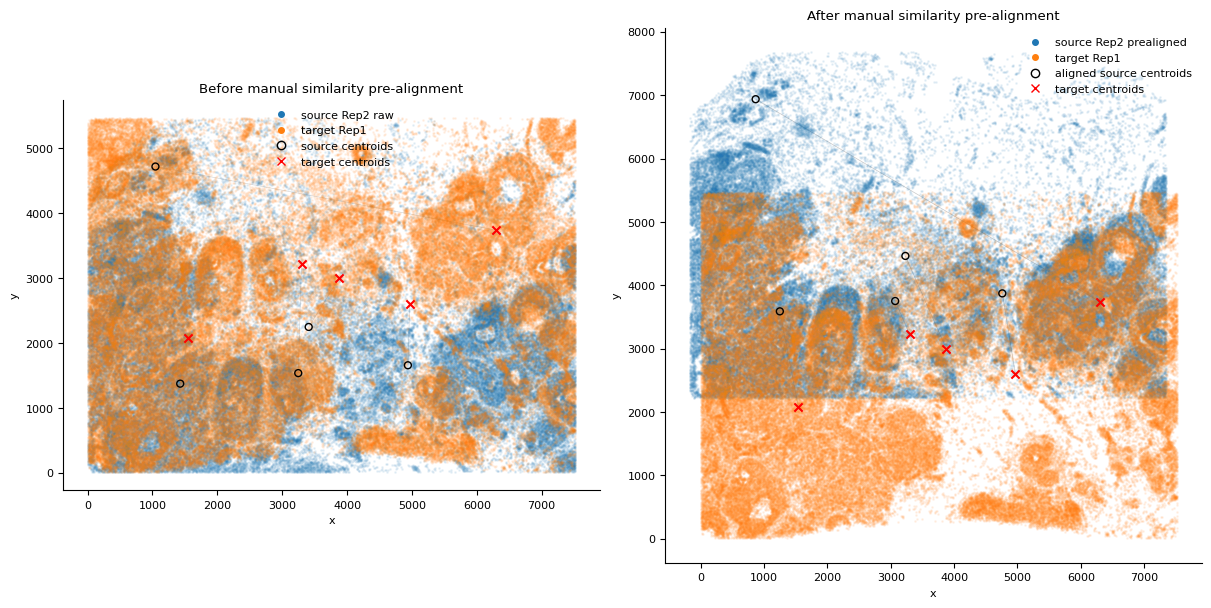

In [2]:
manual_config = spAlignDE.ManualPrealignmentConfig(
    scale=float(os.environ.get("SPALIGNDE_MANUAL_SCALE", 1.0)),
    theta_deg=float(os.environ.get("SPALIGNDE_MANUAL_THETA_DEG", 0.0)),
    translation_x=float(
        os.environ.get("SPALIGNDE_MANUAL_TX", -177.46841472056394)
    ),
    translation_y=float(
        os.environ.get("SPALIGNDE_MANUAL_TY", 2215.1264424752544)
    ),
)
prealignment = spAlignDE.prealign_cross_sample_manual(
    adata,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    config=manual_config,
)
for key in ("scale", "theta_deg", "translation_x", "translation_y"):
    print(f"{key}: {prealignment.params[key]}")
spAlignDE.plot_prealignment_result(prealignment)

## Convert cells to continuous pseudo-images

Shared refined clusters define composition channels, and the
log-scaled pooled density channel receives equal optimization
weight.

Shared cluster channels: 5
Pseudo-image shape: (6, 271, 271)
Shared grid: 271 x 271


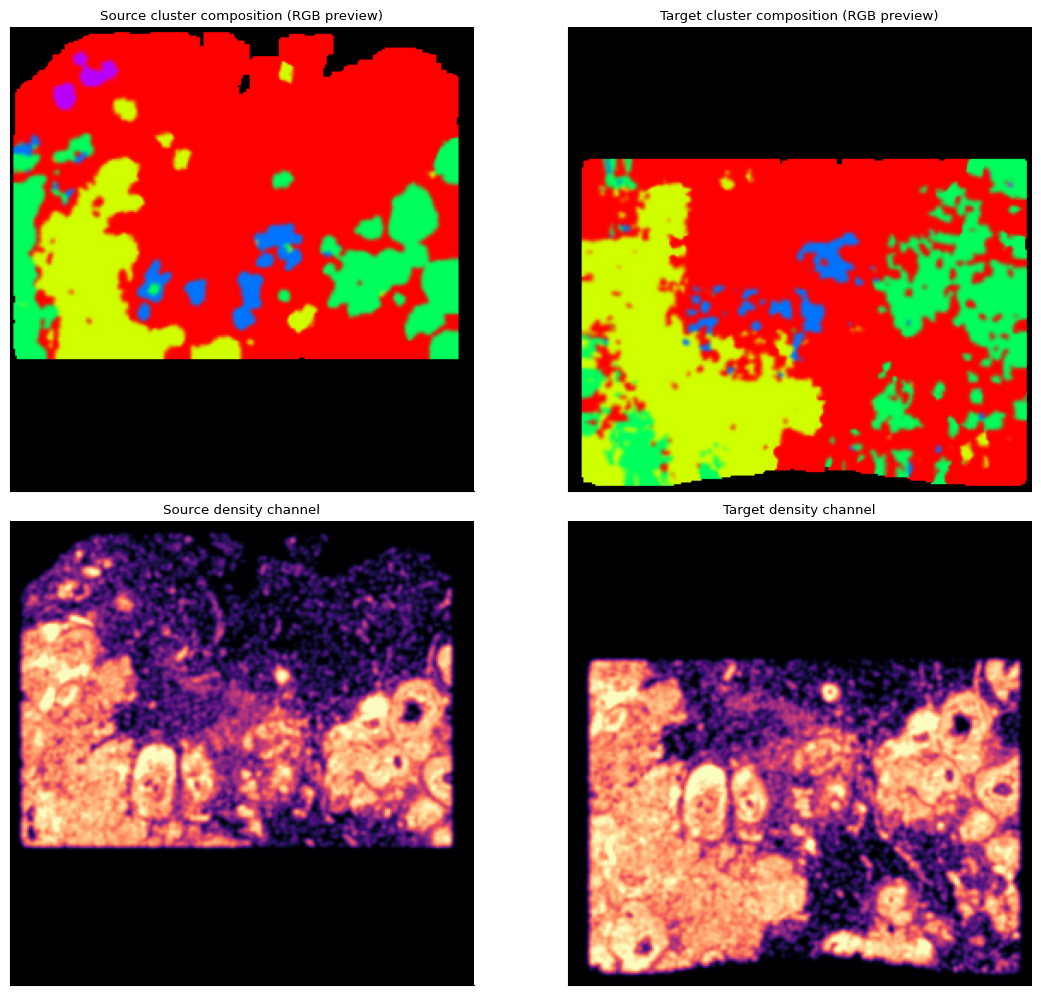

In [3]:
fields = spAlignDE.rasterize_cross_sample(
    prealignment.adata,
    query_sample=QUERY,
    reference_sample=REFERENCE,
    config=spAlignDE.RasterizationConfig(
        grid_spacing=30,
        grid_expand=1.05,
        blur_sigma=1,
        cluster_weight=1,
        density_weight=1,
    ),
)
print("Shared cluster channels:", len(fields.shared_clusters))
print("Pseudo-image shape:", fields.query_image.shape)
print("Shared grid:", len(fields.grid_y), "x", len(fields.grid_x))
spAlignDE.plot_rasterized_fields(fields)

## Shooting-based LDDMM refinement

The selected breast-cancer run retains the original S-LDDMM
settings: `a=300`, `nt=3`, `grid_step=100`, `lrM=4000`, and
`niter=500`.

In [4]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
slddmm_config = spAlignDE.SLDDMMConfig(
    kernel_scale=300,
    kernel_power=2,
    velocity_expand=2,
    time_steps=3,
    velocity_grid_spacing=100,
    iterations=500,
    momentum_lr=4000,
    minimum_momentum_lr=4000,
    momentum_gradient_clip=1000,
    dtype="float32",
)
result = spAlignDE.run_slddmm_alignment(
    prealignment.adata,
    fields,
    config=slddmm_config,
    device=device,
    prealignment=prealignment,
    verbose=True,
    print_every=50,
)
print("Alignment summary:")
for key, value in result.metrics.items():
    print(f"  {key}: {value}")

[LDDMM] start: niter=500, nt=3, device=cuda:0, I_shape=(6, 271, 271), J_shape=(6, 271, 271)


[LDDMM] iter 1/500 E=8.154004e+03 EM=8.154004e+03 ER=0.000000e+00


[LDDMM] iter 51/500 E=7.721306e+03 EM=7.720112e+03 ER=1.193995e+00


[LDDMM] iter 101/500 E=1.452710e+04 EM=1.452071e+04 ER=6.396335e+00


[LDDMM] iter 151/500 E=1.421777e+04 EM=1.420802e+04 ER=9.746833e+00


...

[LDDMM] iter 351/500 E=1.352783e+04 EM=1.350776e+04 ER=2.006910e+01


[LDDMM] iter 401/500 E=1.341119e+04 EM=1.338839e+04 ER=2.280381e+01


[LDDMM] iter 451/500 E=1.331145e+04 EM=1.328605e+04 ER=2.539669e+01


[LDDMM] iter 500/500 E=1.321781e+04 EM=1.318979e+04 ER=2.802428e+01
[LDDMM] done in 6.3s. finalE=1.321781e+04


Alignment summary:
  nearest_label_agreement_prealigned: 0.6302112777272074
  nearest_label_agreement_aligned: 0.7273511234609303
  nearest_label_agreement_gain: 0.09713984573372292
  elapsed_seconds: 6.323710918426514
  n_shared_clusters: 5
  device: cuda:0


### How to adapt rasterization and S-LDDMM parameters

First confirm that the global pre-alignment is anatomically plausible and that
the rasterized shared structures overlap. S-LDDMM should refine an already
credible initialization, not repair a wrong rotation, scale, reflection or
cluster correspondence.

- `grid_spacing` is the structural-image resolution. Smaller values preserve
  detail but increase memory and sensitivity to sparse sampling.
- `blur_sigma` is measured in raster pixels. Increase it for fragmented sparse
  fields; decrease it if adjacent thin structures merge.
- `density_weight` is useful when sampling density describes tissue shape. It
  can be reduced or set to zero for approximately regular spot grids.
- `kernel_scale` is legacy `a`. Increasing it makes deformation smoother and
  more global; decreasing it permits more local bending and raises overfitting
  risk.
- `velocity_grid_spacing` is legacy `grid_step`. Decreasing it creates a denser
  velocity field with more memory/runtime and local flexibility; increasing it
  produces a coarser, more regularized field. Tune it together with `a`.
- `time_steps` (`nt`) controls integration accuracy rather than deformation
  amplitude. `iterations` (`niter`) controls optimization duration.
- Increase `momentum_lr` (`lrM`) only when energy decreases stably but too
  slowly; reduce it if energy oscillates, becomes non-finite or the warp is
  implausibly local.

All distance-valued settings use the coordinates passed to this stage. Do not
copy `a`, `grid_step`, raster spacing or translations between differently
scaled datasets without rescaling and rechecking the velocity-grid dimensions.

## Alignment visual comparisons

The first figure emphasizes tissue geometry without cluster
colors. The second uses the shared cluster palette to expose local
structural correspondence before and after S-LDDMM.

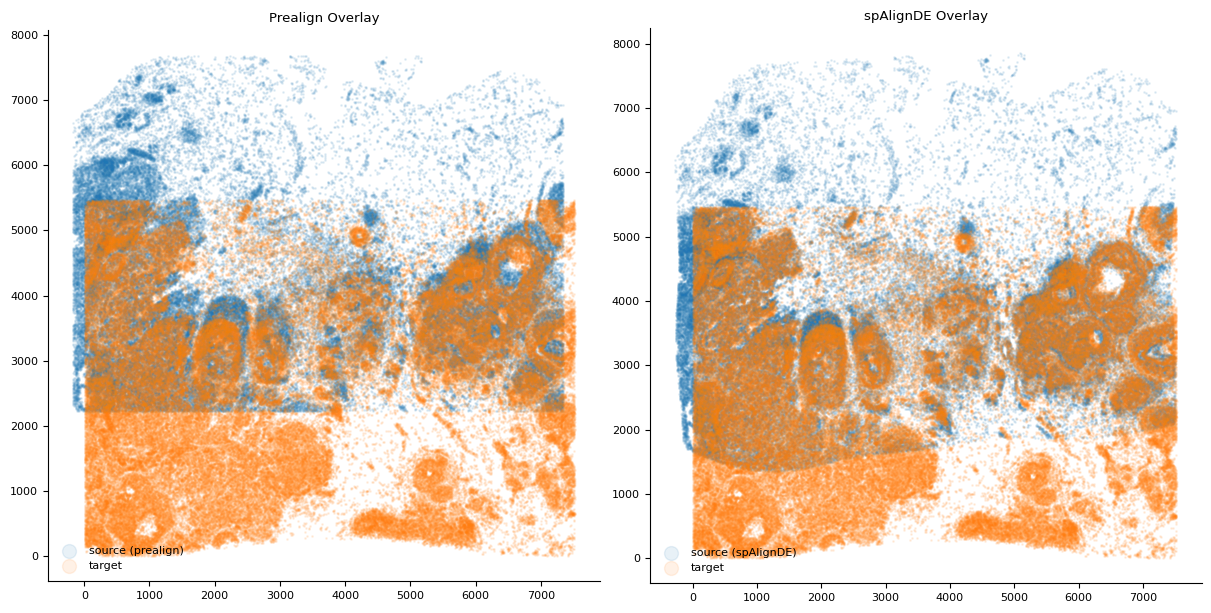

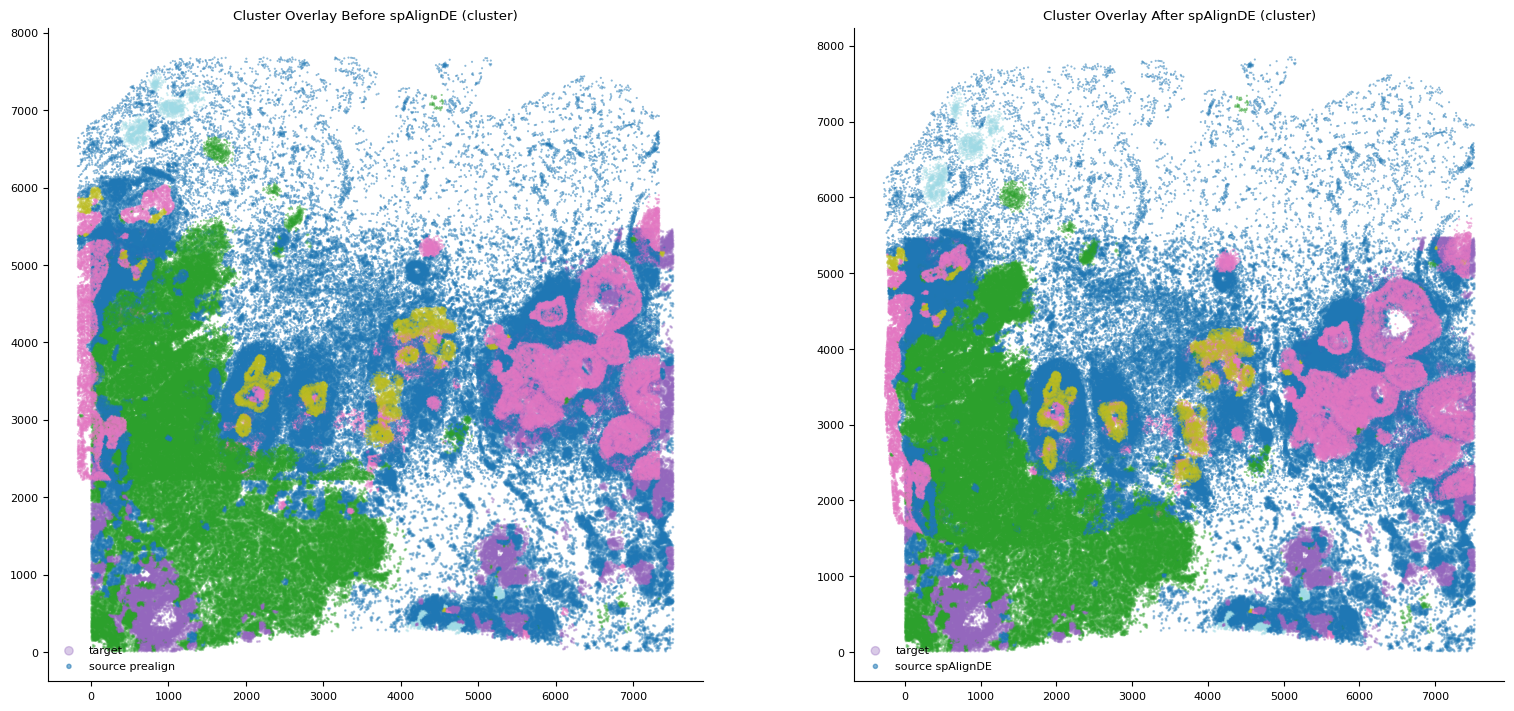

,cluster,n_cells,prealign_match_rate,lddmm_match_rate,prealign_mean_nn_dist,lddmm_mean_nn_dist,match_rate_gain
0,0,47466,0.730228,0.808157,189.663693,134.145161,0.077929
1,1,23946,0.696484,0.853545,29.812483,18.291137,0.157062
2,2,25496,0.508197,0.574012,30.889593,25.335144,0.065814
3,3,6240,0.236538,0.396795,29.856819,12.302744,0.160256
4,4,1217,0.000000,0.000000,1471.835436,1074.057291,0.000000


In [5]:
spAlignDE.plot_alignment_result(result)
spAlignDE.plot_cluster_alignment_result(result)
result.cluster_performance.sort_values("cluster")

## Save the aligned breast-cancer AnnData

Rep1 remains fixed. Rep2 pre-aligned and final coordinates are
written to the four standardized output columns.

In [6]:
aligned_path = OUTPUT_DIR / "breast_cancer_Rep2_to_Rep1_aligned.h5ad"
result.adata.write_h5ad(aligned_path)

output_columns = ["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]
sample = result.adata.obs["sample_id"].astype(str)
reference_mask = sample.eq(REFERENCE).to_numpy()
reference_output = result.adata.obs.loc[
    reference_mask, output_columns
].to_numpy(dtype=float)
reference_raw = np.asarray(result.adata.obsm["spatial"])[reference_mask]
assert np.allclose(reference_output[:, :2], reference_raw)
assert np.allclose(reference_output[:, 2:], reference_raw)

print("Saved:", aligned_path.relative_to(PROJECT_ROOT))
print(result.adata.obs.loc[sample.eq(QUERY), output_columns].head())
print("Reference coordinates verified unchanged.")

Saved: tutorials/cross_sample/breast_cancer/output/breast_cancer_Rep2_to_Rep1_aligned.h5ad
        x_prealigned  y_prealigned   x_aligned    y_aligned
Rep2_1    302.466052   3084.916076  174.710800  2572.110596
Rep2_2    303.788574   3066.815807  178.377899  2550.386230
Rep2_3    313.178833   3070.942644  186.185150  2554.529297
Rep2_4    313.709304   3081.969350  185.141647  2567.680664
Rep2_5    315.371276   3057.637633  189.970459  2538.414062
Reference coordinates verified unchanged.
